# Decision trees from scratch: high-CO operating regions

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/tree-based/01-decision-trees-from-scratch.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Decision trees replace one global equation with a sequence of simple rules. In this notebook, we predict whether a gas-turbine operating observation has **high CO**: measured carbon monoxide at least 2 mg/m³.

We will first build the first two splits ourselves using Gini impurity. Then we will ask scikit-learn to fit and draw the same shallow tree. The goal is to understand the splitting logic before relying on a library implementation.

## 1. Set up the classification task

Each row in the dataset records one gas-turbine operating observation. `high_co` is our binary target. We offer the tree the measured operating quantities, but exclude `CO` itself because the target was defined from that measurement.

We reserve 30% of the usable observations as a test set. We will build the tree only with the training observations, then check its simple held-out accuracy at the end.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid", context="notebook")

DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])

# In Google Colab, download the small course dataset if it is not already present.
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "high_co"

# Keep one complete set of measured features for this first implementation.
model_data = data[FEATURES + [TARGET]].dropna().copy()
X_train, X_test, y_train, y_test = train_test_split(
    model_data[FEATURES],
    model_data[TARGET],
    test_size=0.30,
    random_state=4520,
    stratify=model_data[TARGET],
)

print(f"Usable operating observations: {len(model_data):,}")
print(f"Training observations: {len(X_train):,}")
print(f"Held-out test observations: {len(X_test):,}")
print(f"High-CO fraction in training data: {y_train.mean():.1%}")

Usable operating observations: 35,398
Training observations: 24,778
Held-out test observations: 10,620
High-CO fraction in training data: 38.8%


## 2. Measure class mixing with Gini impurity

A tree divides the observations into **regions**. For a region \(R\), let \(q_R\) be the fraction of high-CO observations. The Gini impurity is

$$
G(R) = 1-q_R^2-(1-q_R)^2 = 2q_R(1-q_R).
$$

It is zero when a region contains only one class, and largest when the two classes are evenly mixed. A classification tree chooses the split that produces the largest reduction in the sample-size-weighted Gini impurity.

In [2]:
def gini_impurity(labels: pd.Series | np.ndarray) -> float:
    """Compute binary Gini impurity for one region.

    Args:
        labels: Binary high-CO labels in the region.

    Returns:
        The region's Gini impurity.
    """
    positive_fraction = np.mean(labels)
    return float(2 * positive_fraction * (1 - positive_fraction))


def region_summary(labels: pd.Series | np.ndarray) -> dict[str, float | int | str]:
    """Summarize a region using its observed labels.

    Args:
        labels: Binary high-CO labels in the region.

    Returns:
        Sample count, high-CO fraction, Gini impurity, and majority-class label.
    """
    high_co_fraction = float(np.mean(labels))
    return {
        "samples": len(labels),
        "high-CO fraction": high_co_fraction,
        "Gini impurity": gini_impurity(labels),
        "majority class": "High CO" if high_co_fraction >= 0.5 else "CO < 2 mg/m³",
    }

pd.DataFrame([region_summary(y_train)], index=["All training observations"]).round(3)

,samples,high-CO fraction,Gini impurity,majority class
All training observations,24778,0.388,0.475,CO < 2 mg/m³


## 3. Score one proposed split

Suppose we propose splitting turbine inlet temperature (TIT) at 1076.95 °C. The observations at or below the cutpoint form the left region; the rest form the right region.

The loss after a split is the weighted average of the two child impurities:

$$
G_{\mathrm{after}} = \frac{n_L}{n}G(R_L) + \frac{n_R}{n}G(R_R).
$$

The resulting Gini decrease is \(G(R)-G_{\mathrm{after}}\).

In [3]:
def score_split(
    feature_values: pd.Series, labels: pd.Series, threshold: float
) -> tuple[dict[str, float], pd.Series, pd.Series]:
    """Score one binary cutpoint with weighted Gini impurity.

    Args:
        feature_values: Values of one candidate feature in the parent region.
        labels: Binary high-CO labels in the same row order.
        threshold: Values at or below this cutpoint go to the left child.

    Returns:
        Split metrics plus the labels in the left and right child regions.
    """
    left_labels = labels[feature_values <= threshold]
    right_labels = labels[feature_values > threshold]
    n_total = len(labels)

    weighted_child_gini = (
        len(left_labels) / n_total * gini_impurity(left_labels)
        + len(right_labels) / n_total * gini_impurity(right_labels)
    )
    parent_gini = gini_impurity(labels)
    return (
        {
            "parent Gini": parent_gini,
            "weighted child Gini": weighted_child_gini,
            "Gini decrease": parent_gini - weighted_child_gini,
        },
        left_labels,
        right_labels,
    )

proposed_threshold = 1076.95
score, left_labels, right_labels = score_split(
    X_train["TIT"], y_train, proposed_threshold
)

summary = pd.DataFrame(
    [
        region_summary(y_train),
        region_summary(left_labels),
        region_summary(right_labels),
    ],
    index=[
        "Parent region",
        f"TIT ≤ {proposed_threshold:.2f} °C",
        f"TIT > {proposed_threshold:.2f} °C",
    ],
)
display(summary.round(3))
pd.Series(score).round(3)

,samples,high-CO fraction,Gini impurity,majority class
Parent region,24778,0.388,0.475,CO < 2 mg/m³
TIT ≤ 1076.95 °C,7648,0.880,0.212,High CO
TIT > 1076.95 °C,17130,0.169,0.281,CO < 2 mg/m³


parent Gini            0.475
weighted child Gini    0.260
Gini decrease          0.215
dtype: float64

## 4. Search for the best first split

Rather than specify one feature and cutpoint ourselves, the tree searches them. For each feature, candidate cutpoints lie halfway between adjacent distinct observed values.

The function below sorts one feature at a time, uses cumulative counts of high-CO labels, and scores every valid cutpoint. This gives the same greedy search logic as a decision-tree library while keeping the calculation practical for the full training dataset.

In [4]:
def find_best_gini_split(
    features: pd.DataFrame, labels: pd.Series
) -> dict[str, float | int | str]:
    """Find the feature and cutpoint with the smallest weighted Gini impurity.

    Args:
        features: Candidate feature columns for one parent region.
        labels: Binary high-CO labels for the same observations.
    Returns:
        Details of the best valid binary split in the region.
    """
    label_values = labels.to_numpy(dtype=int)
    n_samples = len(label_values)
    parent_gini = gini_impurity(label_values)
    best_split: dict[str, float | int | str] | None = None

    for feature_name in features.columns:
        values = features[feature_name].to_numpy()
        order = np.argsort(values, kind="stable")
        sorted_values = values[order]
        sorted_labels = label_values[order]

        # A candidate cutpoint sits between two distinct adjacent values.
        left_sizes = np.arange(1, n_samples)
        right_sizes = n_samples - left_sizes
        left_positive = np.cumsum(sorted_labels)[:-1]
        right_positive = sorted_labels.sum() - left_positive
        valid = sorted_values[:-1] < sorted_values[1:]
        if not valid.any():
            continue

        left_fraction = left_positive / left_sizes
        right_fraction = right_positive / right_sizes
        left_gini = 2 * left_fraction * (1 - left_fraction)
        right_gini = 2 * right_fraction * (1 - right_fraction)
        weighted_gini = (
            left_sizes * left_gini + right_sizes * right_gini
        ) / n_samples

        candidate_index = np.where(valid, weighted_gini, np.inf).argmin()
        candidate_gini = float(weighted_gini[candidate_index])
        if best_split is None or candidate_gini < best_split["weighted child Gini"]:
            best_split = {
                "feature": feature_name,
                "threshold": float(
                    (sorted_values[candidate_index] + sorted_values[candidate_index + 1]) / 2
                ),
                "parent Gini": parent_gini,
                "weighted child Gini": candidate_gini,
                "Gini decrease": parent_gini - candidate_gini,
                "left samples": int(left_sizes[candidate_index]),
                "right samples": int(right_sizes[candidate_index]),
            }

    if best_split is None:
        raise ValueError("No split is available for this region.")
    return best_split

first_split = find_best_gini_split(X_train, y_train)
pd.Series(first_split).to_frame("best first split")

,best first split
feature,TIT
threshold,1076.95
parent Gini,0.475113
weighted child Gini,0.259617
Gini decrease,0.215496
left samples,7648
right samples,17130


## 5. Choose the second split

After the first split, each child is a candidate for further division. A best-first tree asks which available child split delivers the largest **overall** reduction in training-set impurity. That requires weighting each child region's local Gini decrease by the fraction of training observations that reach it.

We stop after this second split so the rules remain easy to inspect. A deeper tree simply repeats the same search.

In [5]:
root_feature = str(first_split["feature"])
root_threshold = float(first_split["threshold"])
left_mask = X_train[root_feature] <= root_threshold
right_mask = ~left_mask

left_candidate = find_best_gini_split(
    X_train.loc[left_mask], y_train.loc[left_mask]
)
right_candidate = find_best_gini_split(
    X_train.loc[right_mask], y_train.loc[right_mask]
)

second_split_candidates = pd.DataFrame(
    [
        {
            "parent region": f"{root_feature} ≤ {root_threshold:.2f}",
            **left_candidate,
            "overall Gini decrease": left_mask.mean() * left_candidate["Gini decrease"],
        },
        {
            "parent region": f"{root_feature} > {root_threshold:.2f}",
            **right_candidate,
            "overall Gini decrease": right_mask.mean() * right_candidate["Gini decrease"],
        },
    ]
).sort_values("overall Gini decrease", ascending=False)

display(
    second_split_candidates[
        [
            "parent region",
            "feature",
            "threshold",
            "Gini decrease",
            "overall Gini decrease",
        ]
    ].round(3)
)

second_split = second_split_candidates.iloc[0]
print(
    "The second split divides the region "
    f"{second_split['parent region']} using "
    f"{second_split['feature']} ≤ {second_split['threshold']:.3f}."
)

,parent region,feature,threshold,Gini decrease,overall Gini decrease
1,TIT > 1076.95,AFDP,3.51,0.012,0.009
0,TIT ≤ 1076.95,TIT,1059.85,0.022,0.007


The second split divides the region TIT > 1076.95 using AFDP ≤ 3.510.


## 6. Reproduce the shallow tree with scikit-learn

`DecisionTreeClassifier` carries out this search efficiently. Setting `max_leaf_nodes=3` permits exactly two internal splits, creating three final regions. We use the same Gini criterion as in our implementation above.

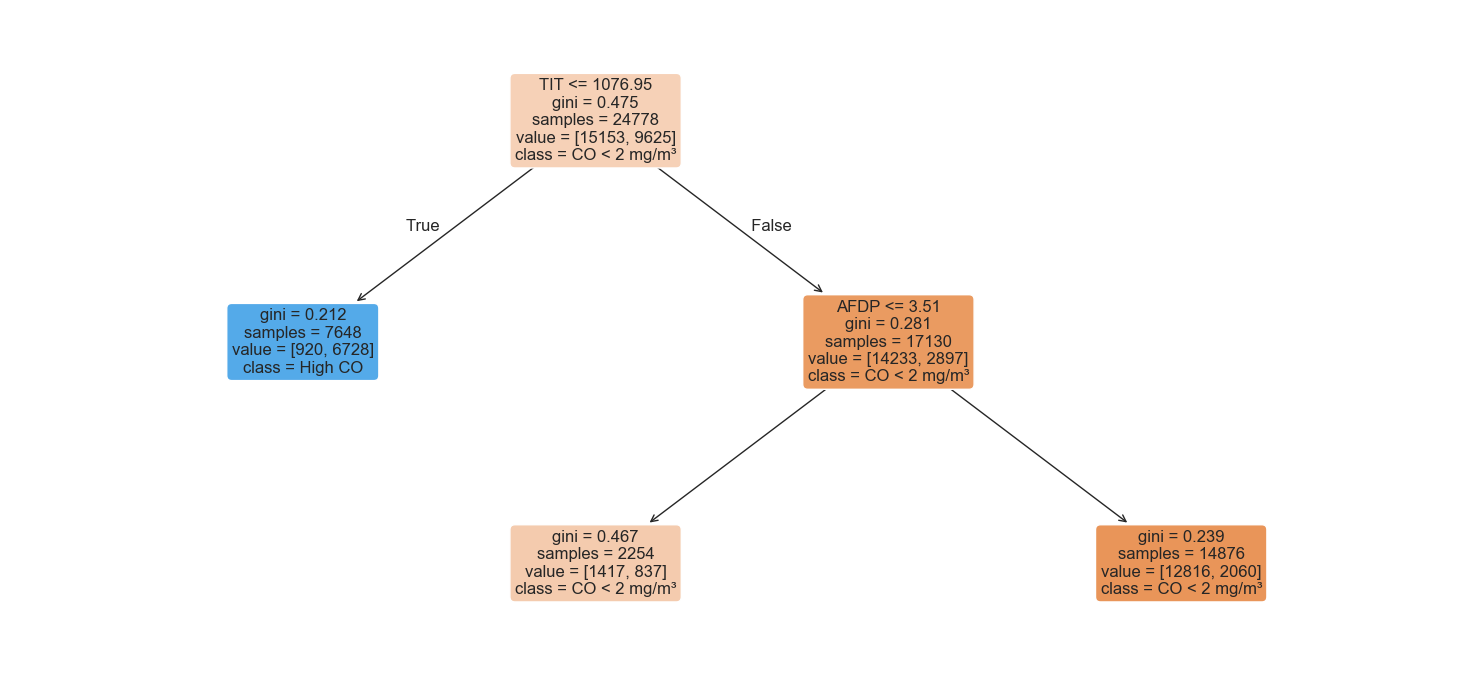

In [6]:
tree = DecisionTreeClassifier(
    criterion="gini",
    max_leaf_nodes=3,
    random_state=4520,
)
tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=["CO < 2 mg/m³", "High CO"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    precision=3,
    fontsize=12,
    ax=ax,
)
ax.set_axis_off()
fig.tight_layout()
plt.show()

In [7]:
print(f"Training accuracy: {tree.score(X_train, y_train):.3f}")
print(f"Held-out test accuracy: {tree.score(X_test, y_test):.3f}")

Training accuracy: 0.846
Held-out test accuracy: 0.845


## Takeaways

- A classification tree creates regions in feature space and assigns each leaf the majority class. The fraction of high-CO observations in a leaf also provides a simple probability estimate.
- Each split greedily reduces weighted Gini impurity. It does not search jointly for every later split.
- Here, the first rule uses TIT. The second rule uses AFDP within one TIT region.
- Trees can keep splitting until they memorize training observations, so later we will tune their depth and leaf-size controls using held-out data.

[Return to Tree-based](index.qmd)